# Projeto Final - Equipe Vasco da Gama


- Juan Pablo do Egito Jimenez - 202307040009
- Samuel Meireles Maciejewsky - 202307040008
- Jose Antonio da Silva Pinto Junior - 202306840051




Este notebook reutiliza o ambiente `MassiveMIMOEnv` do repositorio `rl-wireless` para treinar agentes de aprendizado por reforco na alocacao de potencia em uma rede Massive MIMO. O objetivo e comparar PPO, DQN e A2C em configuracao padrao e apos ajuste de hiperparametros com Optuna.

## 1. Dependencias

A celula abaixo instala as bibliotecas usadas pelo notebook no ambiente Python do Jupyter.

In [33]:
%pip install -q stable-baselines3 optuna pandas matplotlib seaborn gymnasium numpy scipy numba torch

Note: you may need to restart the kernel to use updated packages.


## 2. Imports e caminhos


In [50]:
from pathlib import Path
from datetime import datetime
import json
import shutil
import sys
import time
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch

from stable_baselines3 import A2C, DQN, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import set_random_seed

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("GPU CUDA nao detectada pelo kernel. O treino usara CPU.")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "rl-wireless").exists() else NOTEBOOK_DIR.parent
RL_WIRELESS_DIR = PROJECT_ROOT / "rl-wireless"
sys.path.insert(0, str(RL_WIRELESS_DIR))

RESULTS_DIR = PROJECT_ROOT / "VASCO_final_project" / "results"
FIGURES_DIR = PROJECT_ROOT / "VASCO_final_project" / "figures"
MODELS_DIR = PROJECT_ROOT / "VASCO_final_project" / "models"
for directory in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

from network import MassiveMIMOEnv



GPU detectada: NVIDIA GeForce RTX 2050


## 3. Configuracao do experimento

Nesta célula nossa equipe configurou o cénario para que a maquina consiga rodar, além do cénario MIMO , é tambem configurado parametros do treinamento PPO,A2C e DQN, `FAST_MODE=True` utiliza configurações leves para teste.

In [35]:
SEED = 0
ENV_ID = "MassiveMIMO-v0"

ENV_CONFIG = {
    "N": 7,     #numero de celulas 
    "M": 32,    #numero de antenas por BS
    "K": 4,    #user equipaments
    "Ns": 10,   # Number of samples for the channel realization
    "min_P": -20, #mim power in Dbm
    "max_P": 23,  # max power in Dbm
    "num_P": 10, # unmber of power levels discretized
    "dtype": np.float32,
}

# Use True only for quick smoke tests. Final/report runs should keep False.
FAST_MODE = False

if FAST_MODE:
    DEFAULT_TRAIN_TIMESTEPS = 5_000
    OPTUNA_TRAIN_TIMESTEPS = 3_000
    FINAL_TRAIN_TIMESTEPS = 8_000
    N_TRIALS = 5
    EVAL_EPISODES = 10
    OPTUNA_PRUNER_EVAL_EPISODES = 5
else:
    DEFAULT_TRAIN_TIMESTEPS = 15_000
    OPTUNA_TRAIN_TIMESTEPS = 5_000
    FINAL_TRAIN_TIMESTEPS = 25_000
    N_TRIALS = 12
    EVAL_EPISODES = 15
    OPTUNA_PRUNER_EVAL_EPISODES = 5

OPTUNA_EVAL_FREQ = max(1_000, OPTUNA_TRAIN_TIMESTEPS // 4)
CUSTOM_RUN_ID = None  # Example: "20260720_final_run" to resume/reuse a named run.
RUN_ID = CUSTOM_RUN_ID or datetime.now().strftime("%Y%m%d_%H%M%S_vasco_optuna")

CLEAR_PREVIOUS_TOP_LEVEL_RESULTS = True
TOP_LEVEL_RESULT_FILES = [
    "summary_results.csv",
    "training_curves.csv",
    "evaluation_episodes.csv",
    "stability_summary.csv",
    "experiment_config.json",
    "optuna_ppo_trials.csv",
    "optuna_dqn_trials.csv",
    "optuna_a2c_trials.csv",
]
TOP_LEVEL_RESULT_DIRS = ["monitor", "tensorboard"]

TOP_LEVEL_FIGURE_FILES = [
    "learning_curves.png",
    "mean_reward_training.png",
    "min_reward_training.png",
    "reward_distribution.png",
    "final_comparison.png",
    "optuna_history.png",
    "optuna_param_importance.png",
    "stability_summary.png",
]

RUN_RESULTS_DIR = RESULTS_DIR / "runs" / RUN_ID
RUN_FIGURES_DIR = FIGURES_DIR / "runs" / RUN_ID
RUN_MODELS_DIR = MODELS_DIR / "runs" / RUN_ID
RUN_MONITOR_DIR = RUN_RESULTS_DIR / "monitor"
RUN_TENSORBOARD_DIR = RUN_RESULTS_DIR / "tensorboard"
RUN_OPTUNA_DB = RUN_RESULTS_DIR / "optuna_studies.sqlite3"

for directory in [RUN_RESULTS_DIR, RUN_FIGURES_DIR, RUN_MODELS_DIR, RUN_MONITOR_DIR, RUN_TENSORBOARD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)
set_random_seed(SEED)

print({
    "run_id": RUN_ID,
    "fast_mode": FAST_MODE,
    "default_train_timesteps": DEFAULT_TRAIN_TIMESTEPS,
    "optuna_train_timesteps": OPTUNA_TRAIN_TIMESTEPS,
    "final_train_timesteps": FINAL_TRAIN_TIMESTEPS,
    "n_trials": N_TRIALS,
    "eval_episodes": EVAL_EPISODES,
    "optuna_pruner_eval_episodes": OPTUNA_PRUNER_EVAL_EPISODES,
    "optuna_eval_freq": OPTUNA_EVAL_FREQ,
    "device": DEVICE,
    "run_results_dir": str(RUN_RESULTS_DIR),
    "run_models_dir": str(RUN_MODELS_DIR),
    "run_figures_dir": str(RUN_FIGURES_DIR),
})


{'run_id': '20260720_170424_vasco_optuna', 'fast_mode': False, 'default_train_timesteps': 15000, 'optuna_train_timesteps': 5000, 'final_train_timesteps': 25000, 'n_trials': 12, 'eval_episodes': 15, 'optuna_pruner_eval_episodes': 5, 'optuna_eval_freq': 1250, 'device': 'cuda', 'run_results_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_170424_vasco_optuna', 'run_models_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/models/runs/20260720_170424_vasco_optuna', 'run_figures_dir': '/home/juan/documents/projeto_ic_MIMO/VASCO_final_project/figures/runs/20260720_170424_vasco_optuna'}


## 4. Registro e validacao do ambiente Gymnasium

In [36]:
from gymnasium.envs.registration import registry

if ENV_ID not in registry:
    gym.register(id=ENV_ID, entry_point="network.environment:MassiveMIMOEnv")

def make_env(seed=None):
    env = gym.make(ENV_ID, **ENV_CONFIG)
    if seed is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
    return env

def make_monitored_vec_env(name, seed=None):
    log_dir = RUN_MONITOR_DIR / name
    log_dir.mkdir(parents=True, exist_ok=True)

    def _init():
        env = make_env(seed=seed)
        return Monitor(env, filename=str(log_dir / f"{name}.monitor.csv"), override_existing=True)

    return DummyVecEnv([_init])

env_check = make_env(seed=SEED)
check_env(env_check.unwrapped, warn=True)
obs, info = env_check.reset(seed=SEED)
action = env_check.action_space.sample()
next_obs, reward, terminated, truncated, info = env_check.step(action)
env_check.close()

env_preview = make_env()
print("Observation space:", env_preview.observation_space)
print("Action space:", env_preview.action_space)
print("Exemplo de observacao inicial:", obs)
print("Exemplo de acao:", action)
print("Exemplo de recompensa:", reward)
print("Shape de downlink_rate:", np.asarray(info["downlink_rate"]).shape)
env_preview.close()


Observation space: Box([-2.0000000e+01 -3.4028235e+38 -3.4028235e+38], [2.3000000e+01 3.4028235e+38 3.4028235e+38], (3,), float32)
Action space: Discrete(10)
Exemplo de observacao inicial: [ 0.04199028 -0.04022276 -0.03430095]
Exemplo de acao: 9
Exemplo de recompensa: 2.721829718143411
Shape de downlink_rate: (7, 4)


## 5. Funcoes de treino e avaliacao

In [37]:
def evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True):
    env = make_env(seed=seed)
    episode_records = []

    for episode in range(n_episodes):
        episode_seed = seed + episode
        obs, info = env.reset(seed=episode_seed)
        terminated = False
        truncated = False
        total_reward = 0.0
        rates = []
        powers = []

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=deterministic)
            if isinstance(action, np.ndarray):
                action = int(action.item())
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += float(reward)
            rates.append(float(np.mean(info["downlink_rate"])))
            powers.append(float(obs[0]))

        episode_records.append({
            "episode": episode + 1,
            "episode_seed": episode_seed,
            "reward": float(total_reward),
            "mean_downlink_rate": float(np.mean(rates)),
            "mean_power_watts": float(np.mean(powers)),
            "deterministic": deterministic,
        })

    env.close()
    rewards = np.array([row["reward"] for row in episode_records], dtype=float)
    rates = np.array([row["mean_downlink_rate"] for row in episode_records], dtype=float)
    powers = np.array([row["mean_power_watts"] for row in episode_records], dtype=float)
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "min_reward": float(np.min(rewards)),
        "max_reward": float(np.max(rewards)),
        "mean_downlink_rate": float(np.mean(rates)),
        "std_downlink_rate": float(np.std(rates)),
        "mean_power_watts": float(np.mean(powers)),
        "std_power_watts": float(np.std(powers)),
        "episodes": episode_records,
    }

class OptunaEvalCallback(BaseCallback):
    def __init__(self, trial, eval_freq, n_eval_episodes, eval_seed, verbose=0):
        super().__init__(verbose=verbose)
        self.trial = trial
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.eval_seed = eval_seed
        self.is_pruned = False
        self.last_mean_reward = None

    def _on_step(self):
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            metrics = evaluate_policy(
                self.model,
                n_episodes=self.n_eval_episodes,
                seed=self.eval_seed + self.n_calls,
                deterministic=True,
            )
            self.last_mean_reward = metrics["mean_reward"]
            self.trial.report(self.last_mean_reward, step=self.n_calls)
            if self.trial.should_prune():
                self.is_pruned = True
                return False
        return True

def train_model(algorithm_cls, name, params, total_timesteps, seed=SEED, callback=None, save_model=True):
    set_random_seed(seed)
    env = make_monitored_vec_env(name=name, seed=seed)
    model = algorithm_cls(
        "MlpPolicy",
        env,
        seed=seed,
        verbose=0,
        device=DEVICE,
        tensorboard_log=str(RUN_TENSORBOARD_DIR),
        **params,
    )

    start = time.perf_counter()
    model.learn(total_timesteps=total_timesteps, progress_bar=False, callback=callback)
    train_time_s = time.perf_counter() - start
    if save_model and not getattr(callback, "is_pruned", False):
        model.save(str(RUN_MODELS_DIR / name))
    env.close()
    return model, train_time_s

def result_row(model_name, algorithm, training_type, metrics, params=None, train_time_s=None, seed=SEED):
    return {
        "run_id": RUN_ID,
        "model": model_name,
        "algorithm": algorithm,
        "training_type": training_type,
        "seed": seed,
        "eval_episodes": EVAL_EPISODES,
        "mean_reward": metrics["mean_reward"],
        "std_reward": metrics["std_reward"],
        "min_reward": metrics["min_reward"],
        "max_reward": metrics["max_reward"],
        "mean_downlink_rate": metrics["mean_downlink_rate"],
        "std_downlink_rate": metrics["std_downlink_rate"],
        "mean_power_watts": metrics["mean_power_watts"],
        "std_power_watts": metrics["std_power_watts"],
        "train_time_s": train_time_s,
        "device": DEVICE,
        "params": params or {},
    }


In [38]:
all_results = []
evaluation_records = []

if CLEAR_PREVIOUS_TOP_LEVEL_RESULTS:
    for filename in TOP_LEVEL_RESULT_FILES:
        path = RESULTS_DIR / filename
        if path.exists():
            path.unlink()
    for dirname in TOP_LEVEL_RESULT_DIRS:
        path = RESULTS_DIR / dirname
        if path.exists():
            shutil.rmtree(path)
    for filename in TOP_LEVEL_FIGURE_FILES:
        path = FIGURES_DIR / filename
        if path.exists():
            path.unlink()
    for path in MODELS_DIR.glob("*.zip"):
        path.unlink()

def json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, type):
        return value.__name__
    if isinstance(value, np.dtype):
        return str(value)
    if value is np.float32:
        return "float32"
    if isinstance(value, np.generic):
        return value.item()
    return str(value)

def save_experiment_config():
    config = {
        "run_id": RUN_ID,
        "seed": SEED,
        "env_id": ENV_ID,
        "env_config": ENV_CONFIG,
        "fast_mode": FAST_MODE,
        "default_train_timesteps": DEFAULT_TRAIN_TIMESTEPS,
        "optuna_train_timesteps": OPTUNA_TRAIN_TIMESTEPS,
        "final_train_timesteps": FINAL_TRAIN_TIMESTEPS,
        "n_trials": N_TRIALS,
        "eval_episodes": EVAL_EPISODES,
        "optuna_pruner_eval_episodes": OPTUNA_PRUNER_EVAL_EPISODES,
        "optuna_eval_freq": OPTUNA_EVAL_FREQ,
        "device": DEVICE,
        "run_results_dir": RUN_RESULTS_DIR,
        "run_models_dir": RUN_MODELS_DIR,
        "run_figures_dir": RUN_FIGURES_DIR,
    }
    with open(RUN_RESULTS_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, default=json_default)

save_experiment_config()

def record_result(model_name, algorithm, training_type, metrics, params=None, train_time_s=None, seed=SEED):
    all_results.append(result_row(model_name, algorithm, training_type, metrics, params, train_time_s, seed=seed))
    for episode_row in metrics["episodes"]:
        evaluation_records.append({
            "run_id": RUN_ID,
            "model": model_name,
            "algorithm": algorithm,
            "training_type": training_type,
            "seed": seed,
            **episode_row,
        })

def save_result_tables():
    results_df = pd.DataFrame(all_results)
    evaluation_df = pd.DataFrame(evaluation_records)

    if not results_df.empty:
        results_df.to_csv(RUN_RESULTS_DIR / "summary_results.csv", index=False)
    if not evaluation_df.empty:
        evaluation_df.to_csv(RUN_RESULTS_DIR / "evaluation_episodes.csv", index=False)

    if not evaluation_df.empty:
        stability_df = (
            evaluation_df.groupby(["run_id", "model", "algorithm", "training_type"], as_index=False)
            .agg(
                mean_reward=("reward", "mean"),
                std_reward=("reward", "std"),
                min_reward=("reward", "min"),
                max_reward=("reward", "max"),
                mean_downlink_rate=("mean_downlink_rate", "mean"),
                std_downlink_rate=("mean_downlink_rate", "std"),
                mean_power_watts=("mean_power_watts", "mean"),
                std_power_watts=("mean_power_watts", "std"),
                episodes=("episode", "count"),
            )
        )
        stability_df.to_csv(RUN_RESULTS_DIR / "stability_summary.csv", index=False)

    return results_df

def publish_latest_artifacts():
    for filename in TOP_LEVEL_RESULT_FILES:
        source = RUN_RESULTS_DIR / filename
        if source.exists():
            shutil.copy2(source, RESULTS_DIR / filename)
    for source in RUN_FIGURES_DIR.glob("*.png"):
        shutil.copy2(source, FIGURES_DIR / source.name)
    for source in RUN_MODELS_DIR.glob("*.zip"):
        shutil.copy2(source, MODELS_DIR / source.name)

print("Resultados desta execucao serao salvos em:", RUN_RESULTS_DIR)


Resultados desta execucao serao salvos em: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_170424_vasco_optuna


## 6. Treinamento padrao: PPO, DQN e A2C

In [39]:
ppo_default_params = {
    "learning_rate": 3e-4,
    "n_steps": 256,
    "batch_size": 64,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_range": 0.2,
    "ent_coef": 0.0,
}

dqn_default_params = {
    "learning_rate": 1e-3,
    "buffer_size": 50_000,
    "learning_starts": 1_000,
    "batch_size": 64,
    "gamma": 0.99,
    "train_freq": 4,
    "gradient_steps": 1,
    "target_update_interval": 500,
    "exploration_fraction": 0.2,
    "exploration_final_eps": 0.05,
}

a2c_default_params = {
    "learning_rate": 7e-4,
    "n_steps": 64,
    "gamma": 0.99,
    "gae_lambda": 1.0,
    "ent_coef": 0.0,
    "vf_coef": 0.5,
    "max_grad_norm": 0.5,
}

ppo_default, ppo_default_time = train_model(PPO, "ppo_default", ppo_default_params, DEFAULT_TRAIN_TIMESTEPS)
ppo_default_metrics = evaluate_policy(ppo_default, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("ppo_default", "PPO", "default", ppo_default_metrics, ppo_default_params, ppo_default_time)

dqn_default, dqn_default_time = train_model(DQN, "dqn_default", dqn_default_params, DEFAULT_TRAIN_TIMESTEPS)
dqn_default_metrics = evaluate_policy(dqn_default, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("dqn_default", "DQN", "default", dqn_default_metrics, dqn_default_params, dqn_default_time)

a2c_default, a2c_default_time = train_model(A2C, "a2c_default", a2c_default_params, DEFAULT_TRAIN_TIMESTEPS)
a2c_default_metrics = evaluate_policy(a2c_default, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("a2c_default", "A2C", "default", a2c_default_metrics, a2c_default_params, a2c_default_time)

results_df = save_result_tables()
results_df.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,mean_downlink_rate,std_downlink_rate,mean_power_watts,std_power_watts,train_time_s,device
0,20260720_170424_vasco_optuna,ppo_default,PPO,default,0,15,24.448214,3.434583,17.503733,28.389049,2.444821,0.343458,0.199526,0.0,444.803179,cuda
1,20260720_170424_vasco_optuna,dqn_default,DQN,default,0,15,23.132946,3.258342,16.887224,29.626390,2.313295,0.325834,0.199526,0.0,315.237746,cuda
2,20260720_170424_vasco_optuna,a2c_default,A2C,default,0,15,24.767401,4.265178,17.888910,33.967296,2.476740,0.426518,0.199526,0.0,434.386639,cuda


## 7. Tuning com Optuna - PPO

In [40]:
def sample_ppo_params(trial):
    n_steps = trial.suggest_categorical("n_steps", [256, 512, 1024, 2048])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    if batch_size > n_steps:
        batch_size = n_steps
    return {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True),
        "n_steps": n_steps,
        "batch_size": batch_size,
        "gamma": trial.suggest_float("gamma", 0.93, 0.999),
        "gae_lambda": trial.suggest_float("gae_lambda", 0.85, 0.99),
        "clip_range": trial.suggest_float("clip_range", 0.10, 0.30),
        "ent_coef": trial.suggest_float("ent_coef", 0.0, 0.01),
    }

def objective_ppo(trial):
    params = sample_ppo_params(trial)
    model_name = f"optuna_ppo_trial_{trial.number:03d}"
    callback = OptunaEvalCallback(
        trial,
        eval_freq=OPTUNA_EVAL_FREQ,
        n_eval_episodes=OPTUNA_PRUNER_EVAL_EPISODES,
        eval_seed=SEED + 1000 + trial.number,
    )
    model, train_time_s = train_model(
        PPO,
        model_name,
        params,
        OPTUNA_TRAIN_TIMESTEPS,
        seed=SEED + trial.number,
        callback=callback,
        save_model=False,
    )
    if callback.is_pruned:
        raise optuna.TrialPruned()
    metrics = evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED + 1000 + trial.number, deterministic=True)
    trial.set_user_attr("mean_downlink_rate", metrics["mean_downlink_rate"])
    trial.set_user_attr("std_reward", metrics["std_reward"])
    trial.set_user_attr("train_time_s", train_time_s)
    return metrics["mean_reward"]

study_ppo = optuna.create_study(
    direction="maximize",
    study_name="vasco_ppo_tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=OPTUNA_EVAL_FREQ),
    storage=f"sqlite:///{RUN_OPTUNA_DB}",
    load_if_exists=True,
)
study_ppo.optimize(objective_ppo, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

print("Melhor recompensa PPO:", study_ppo.best_value)
print("Melhores hiperparametros PPO:")
study_ppo.best_params


[I 2026-07-20 17:24:30,454] A new study created in RDB with name: vasco_ppo_tuning
Best trial: 0. Best value: 25.1016:   8%|▊         | 1/12 [02:45<30:15, 165.06s/it]

[I 2026-07-20 17:27:15,508] Trial 0 finished with value: 25.10155713003713 and parameters: {'n_steps': 512, 'batch_size': 256, 'learning_rate': 0.002537737958414811, 'gamma': 0.9564574647989786, 'gae_lambda': 0.9608415053315731, 'clip_range': 0.2057789839505809, 'ent_coef': 0.0056804456109393235}. Best is trial 0 with value: 25.10155713003713.


Best trial: 0. Best value: 25.1016:  17%|█▋        | 2/12 [05:29<27:28, 164.90s/it]

[I 2026-07-20 17:30:00,305] Trial 1 finished with value: 23.864000220013143 and parameters: {'n_steps': 256, 'batch_size': 256, 'learning_rate': 0.0011897025245313022, 'gamma': 0.9618420759954524, 'gae_lambda': 0.9592740846801038, 'clip_range': 0.12365488517378664, 'ent_coef': 0.006399210213275238}. Best is trial 0 with value: 25.10155713003713.


Best trial: 0. Best value: 25.1016:  25%|██▌       | 3/12 [08:16<24:53, 165.91s/it]

...

Best trial: 3. Best value: 26.1575:  92%|█████████▏| 11/12 [29:44<02:11, 131.05s/it]

[I 2026-07-20 17:54:15,084] Trial 10 pruned. 


Best trial: 3. Best value: 26.1575: 100%|██████████| 12/12 [32:44<00:00, 163.74s/it]

[I 2026-07-20 17:57:15,300] Trial 11 finished with value: 23.093534000472896 and parameters: {'n_steps': 256, 'batch_size': 32, 'learning_rate': 7.671146210447024e-05, 'gamma': 0.9441820863721859, 'gae_lambda': 0.9870581991308, 'clip_range': 0.11352878074848871, 'ent_coef': 0.0007020039193428179}. Best is trial 3 with value: 26.157511619907872.
Melhor recompensa PPO: 26.157511619907872
Melhores hiperparametros PPO:


{'n_steps': 2048,
 'batch_size': 128,
 'learning_rate': 5.432176219989315e-05,
 'gamma': 0.9517645562137688,
 'gae_lambda': 0.9009195079319672,
 'clip_range': 0.21403935408357594,
 'ent_coef': 0.004386015134623203}

## 8. Tuning com Optuna - DQN

In [41]:
def sample_dqn_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "buffer_size": trial.suggest_categorical("buffer_size", [50_000, 100_000, 150_000]),
        "learning_starts": trial.suggest_categorical("learning_starts", [500, 1_000, 2_000]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "gamma": trial.suggest_float("gamma", 0.93, 0.999),
        "train_freq": trial.suggest_categorical("train_freq", [1, 4, 8]),
        "gradient_steps": trial.suggest_categorical("gradient_steps", [1, 2, 4]),
        "target_update_interval": trial.suggest_categorical("target_update_interval", [500, 1_000, 2_000]),
        "exploration_fraction": trial.suggest_float("exploration_fraction", 0.10, 0.40),
        "exploration_final_eps": trial.suggest_float("exploration_final_eps", 0.01, 0.08),
    }

def objective_dqn(trial):
    params = sample_dqn_params(trial)
    model_name = f"optuna_dqn_trial_{trial.number:03d}"
    callback = OptunaEvalCallback(
        trial,
        eval_freq=OPTUNA_EVAL_FREQ,
        n_eval_episodes=OPTUNA_PRUNER_EVAL_EPISODES,
        eval_seed=SEED + 2000 + trial.number,
    )
    model, train_time_s = train_model(
        DQN,
        model_name,
        params,
        OPTUNA_TRAIN_TIMESTEPS,
        seed=SEED + 100 + trial.number,
        callback=callback,
        save_model=False,
    )
    if callback.is_pruned:
        raise optuna.TrialPruned()
    metrics = evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED + 2000 + trial.number, deterministic=True)
    trial.set_user_attr("mean_downlink_rate", metrics["mean_downlink_rate"])
    trial.set_user_attr("std_reward", metrics["std_reward"])
    trial.set_user_attr("train_time_s", train_time_s)
    return metrics["mean_reward"]

study_dqn = optuna.create_study(
    direction="maximize",
    study_name="vasco_dqn_tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=OPTUNA_EVAL_FREQ),
    storage=f"sqlite:///{RUN_OPTUNA_DB}",
    load_if_exists=True,
)
study_dqn.optimize(objective_dqn, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

print("Melhor recompensa DQN:", study_dqn.best_value)
print("Melhores hiperparametros DQN:")
study_dqn.best_params


[I 2026-07-20 17:57:15,436] A new study created in RDB with name: vasco_dqn_tuning
Best trial: 0. Best value: 23.1157:   8%|▊         | 1/12 [01:49<19:59, 109.04s/it]

[I 2026-07-20 17:59:04,479] Trial 0 finished with value: 23.11566502766068 and parameters: {'learning_rate': 0.0006466422717414558, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 128, 'gamma': 0.9846290276277039, 'train_freq': 8, 'gradient_steps': 2, 'target_update_interval': 2000, 'exploration_fraction': 0.3935855026698293, 'exploration_final_eps': 0.06594109949517066}. Best is trial 0 with value: 23.11566502766068.


Best trial: 1. Best value: 24.0714:  17%|█▋        | 2/12 [03:58<20:11, 121.13s/it]

[I 2026-07-20 18:01:14,058] Trial 1 finished with value: 24.071443552468455 and parameters: {'learning_rate': 0.0004804641349751479, 'buffer_size': 50000, 'learning_starts': 1000, 'batch_size': 256, 'gamma': 0.9614743729229419, 'train_freq': 8, 'gradient_steps': 4, 'target_update_interval': 500, 'exploration_fraction': 0.30928935877817954, 'exploration_final_eps': 0.01421578301404889}. Best is trial 1 with value: 24.071443552468455.


Best trial: 1. Best value: 24.0714:  25%|██▌       | 3/12 [05:47<17:19, 115.54s/it]

...

Best trial: 7. Best value: 26.1959:  92%|█████████▏| 11/12 [21:11<01:42, 102.19s/it]

[I 2026-07-20 18:18:26,817] Trial 10 pruned. 


Best trial: 7. Best value: 26.1959: 100%|██████████| 12/12 [21:30<00:00, 107.53s/it]

[I 2026-07-20 18:18:45,804] Trial 11 pruned. 
Melhor recompensa DQN: 26.195908587827216
Melhores hiperparametros DQN:


{'learning_rate': 0.00015236917933309359,
 'buffer_size': 50000,
 'learning_starts': 2000,
 'batch_size': 256,
 'gamma': 0.9973109838451991,
 'train_freq': 1,
 'gradient_steps': 1,
 'target_update_interval': 1000,
 'exploration_fraction': 0.3381093110072262,
 'exploration_final_eps': 0.025674728164226612}

## 9. Tuning com Optuna - A2C

In [42]:
def sample_a2c_params(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 3e-3, log=True),
        "n_steps": trial.suggest_categorical("n_steps", [32, 64, 128, 256, 512]),
        "gamma": trial.suggest_float("gamma", 0.93, 0.999),
        "gae_lambda": trial.suggest_float("gae_lambda", 0.85, 1.0),
        "ent_coef": trial.suggest_float("ent_coef", 0.0, 0.01),
        "vf_coef": trial.suggest_float("vf_coef", 0.2, 0.9),
        "max_grad_norm": trial.suggest_float("max_grad_norm", 0.3, 1.0),
    }

def objective_a2c(trial):
    params = sample_a2c_params(trial)
    model_name = f"optuna_a2c_trial_{trial.number:03d}"
    callback = OptunaEvalCallback(
        trial,
        eval_freq=OPTUNA_EVAL_FREQ,
        n_eval_episodes=OPTUNA_PRUNER_EVAL_EPISODES,
        eval_seed=SEED + 3000 + trial.number,
    )
    model, train_time_s = train_model(
        A2C,
        model_name,
        params,
        OPTUNA_TRAIN_TIMESTEPS,
        seed=SEED + 200 + trial.number,
        callback=callback,
        save_model=False,
    )
    if callback.is_pruned:
        raise optuna.TrialPruned()
    metrics = evaluate_policy(model, n_episodes=EVAL_EPISODES, seed=SEED + 3000 + trial.number, deterministic=True)
    trial.set_user_attr("mean_downlink_rate", metrics["mean_downlink_rate"])
    trial.set_user_attr("std_reward", metrics["std_reward"])
    trial.set_user_attr("train_time_s", train_time_s)
    return metrics["mean_reward"]

study_a2c = optuna.create_study(
    direction="maximize",
    study_name="vasco_a2c_tuning",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=OPTUNA_EVAL_FREQ),
    storage=f"sqlite:///{RUN_OPTUNA_DB}",
    load_if_exists=True,
)
study_a2c.optimize(objective_a2c, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True)

print("Melhor recompensa A2C:", study_a2c.best_value)
print("Melhores hiperparametros A2C:")
study_a2c.best_params


[I 2026-07-20 18:18:45,905] A new study created in RDB with name: vasco_a2c_tuning
Best trial: 0. Best value: 22.7522:   8%|▊         | 1/12 [02:48<30:50, 168.21s/it]

[I 2026-07-20 18:21:34,112] Trial 0 finished with value: 22.752235634390313 and parameters: {'learning_rate': 0.00037561961444998357, 'n_steps': 32, 'gamma': 0.9601935175771258, 'gae_lambda': 0.9837659501173119, 'ent_coef': 0.009636627605010294, 'vf_coef': 0.46840906317804437, 'max_grad_norm': 0.8542075266578653}. Best is trial 0 with value: 22.752235634390313.


Best trial: 1. Best value: 23.7025:  17%|█▋        | 2/12 [04:53<23:48, 142.83s/it]

[I 2026-07-20 18:23:39,173] Trial 1 finished with value: 23.70247844870819 and parameters: {'learning_rate': 0.00034269762466825087, 'n_steps': 64, 'gamma': 0.9874507693428077, 'gae_lambda': 0.9667235126424776, 'ent_coef': 0.008700121482468192, 'vf_coef': 0.8850328395629348, 'max_grad_norm': 0.8594109949517064}. Best is trial 1 with value: 23.70247844870819.


Best trial: 1. Best value: 23.7025:  25%|██▌       | 3/12 [06:50<19:41, 131.27s/it]

...

Best trial: 3. Best value: 24.8976:  92%|█████████▏| 11/12 [24:28<01:40, 100.10s/it]

[I 2026-07-20 18:43:14,901] Trial 10 pruned. 


Best trial: 3. Best value: 24.8976: 100%|██████████| 12/12 [25:09<00:00, 125.83s/it]

[I 2026-07-20 18:43:55,849] Trial 11 pruned. 
Melhor recompensa A2C: 24.897606237531594
Melhores hiperparametros A2C:


{'learning_rate': 0.0004111394517854704,
 'n_steps': 512,
 'gamma': 0.9770456006381404,
 'gae_lambda': 0.9039261850860679,
 'ent_coef': 0.004370319537993415,
 'vf_coef': 0.6883418371490854,
 'max_grad_norm': 0.34215783014048884}

## 10. Retreinamento com melhores hiperparametros

In [43]:
ppo_tuned_params = dict(study_ppo.best_params)
dqn_tuned_params = dict(study_dqn.best_params)
a2c_tuned_params = dict(study_a2c.best_params)

ppo_tuned, ppo_tuned_time = train_model(PPO, "ppo_optuna", ppo_tuned_params, FINAL_TRAIN_TIMESTEPS, seed=SEED)
ppo_tuned_metrics = evaluate_policy(ppo_tuned, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("ppo_optuna", "PPO", "optuna", ppo_tuned_metrics, ppo_tuned_params, ppo_tuned_time)

dqn_tuned, dqn_tuned_time = train_model(DQN, "dqn_optuna", dqn_tuned_params, FINAL_TRAIN_TIMESTEPS, seed=SEED)
dqn_tuned_metrics = evaluate_policy(dqn_tuned, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("dqn_optuna", "DQN", "optuna", dqn_tuned_metrics, dqn_tuned_params, dqn_tuned_time)

a2c_tuned, a2c_tuned_time = train_model(A2C, "a2c_optuna", a2c_tuned_params, FINAL_TRAIN_TIMESTEPS, seed=SEED)
a2c_tuned_metrics = evaluate_policy(a2c_tuned, n_episodes=EVAL_EPISODES, seed=SEED, deterministic=True)
record_result("a2c_optuna", "A2C", "optuna", a2c_tuned_metrics, a2c_tuned_params, a2c_tuned_time)

results_df = save_result_tables()
results_df.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,mean_downlink_rate,std_downlink_rate,mean_power_watts,std_power_watts,train_time_s,device
0,20260720_170424_vasco_optuna,ppo_default,PPO,default,0,15,24.448214,3.434583,17.503733,28.389049,2.444821,0.343458,0.199526,0.000000,444.803179,cuda
1,20260720_170424_vasco_optuna,dqn_default,DQN,default,0,15,23.132946,3.258342,16.887224,29.626390,2.313295,0.325834,0.199526,0.000000,315.237746,cuda
2,20260720_170424_vasco_optuna,a2c_default,A2C,default,0,15,24.767401,4.265178,17.888910,33.967296,2.476740,0.426518,0.199526,0.000000,434.386639,cuda
3,20260720_170424_vasco_optuna,ppo_optuna,PPO,optuna,0,15,23.417121,2.296582,20.281432,28.944495,2.341712,0.229658,0.199526,0.000000,849.265820,cuda
4,20260720_170424_vasco_optuna,dqn_optuna,DQN,optuna,0,15,23.414603,3.933292,11.842878,30.624522,2.341460,0.393329,0.193435,0.022791,643.245713,cuda
5,20260720_170424_vasco_optuna,a2c_optuna,A2C,optuna,0,15,22.627462,3.247423,16.589531,27.473977,2.262746,0.324742,0.199526,0.000000,602.057508,cuda


## 11. Curvas de aprendizado

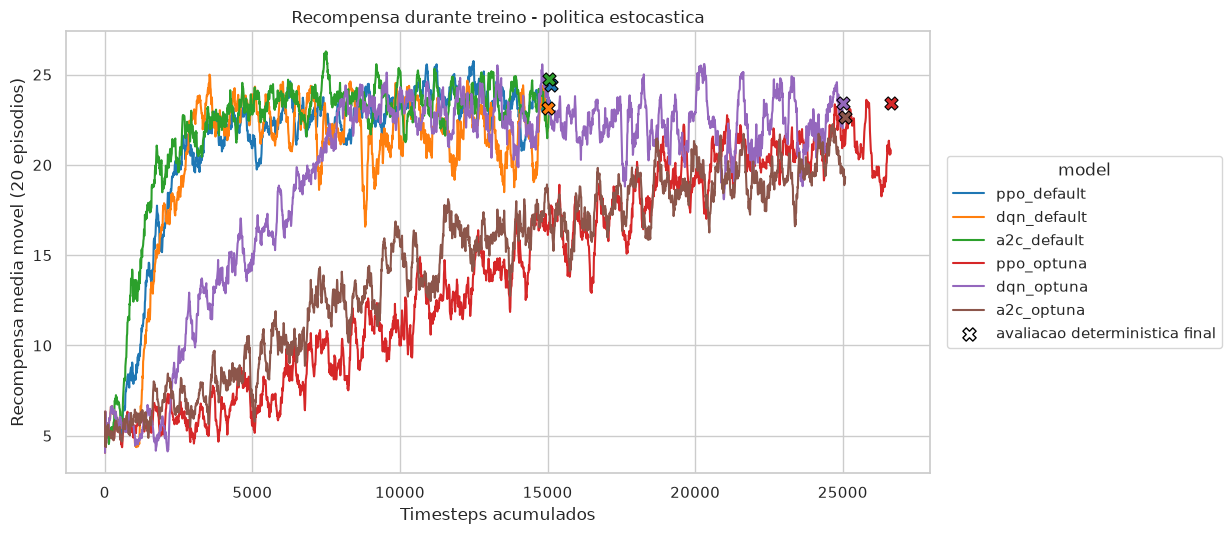

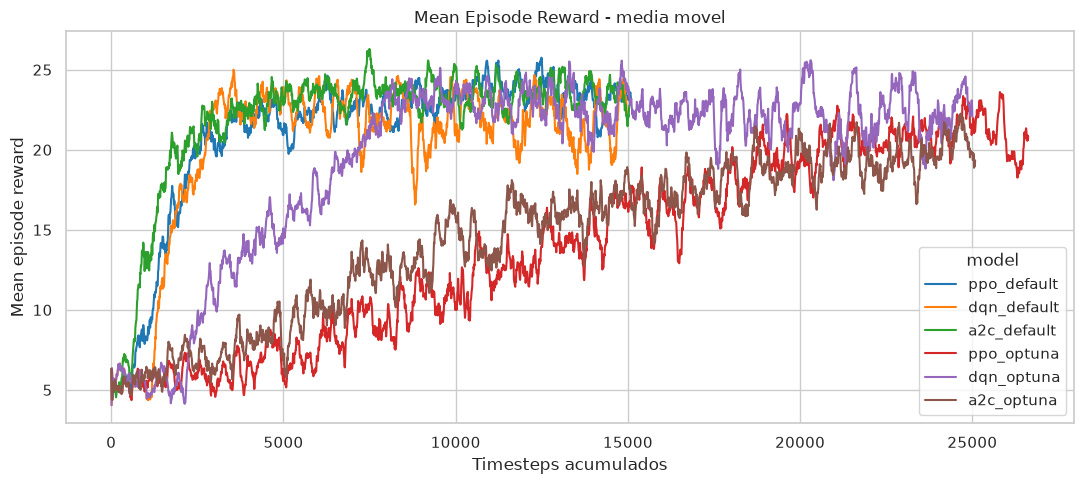

In [49]:
def load_monitor_curves():
    frames = []
    for monitor_file in RUN_MONITOR_DIR.glob("**/*.monitor.csv"):
        df = pd.read_csv(monitor_file, skiprows=1)
        df["model"] = monitor_file.parent.name
        df["episode"] = np.arange(1, len(df) + 1)
        df["timesteps"] = df["l"].cumsum()
        df["rolling_reward"] = df["r"].rolling(window=20, min_periods=1).mean()
        df["rolling_min_reward"] = df["r"].rolling(window=20, min_periods=1).min()
        frames.append(df)
    if not frames:
        return pd.DataFrame(columns=["model", "episode", "timesteps", "r", "rolling_reward", "rolling_min_reward"])
    return pd.concat(frames, ignore_index=True)

curves_df = load_monitor_curves()
curves_df.to_csv(RUN_RESULTS_DIR / "training_curves.csv", index=False)

selected_models = ["ppo_default", "dqn_default", "a2c_default", "ppo_optuna", "dqn_optuna", "a2c_optuna"]
plot_df = curves_df[curves_df["model"].isin(selected_models)].copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=selected_models, ordered=True)
palette = dict(zip(selected_models, sns.color_palette("tab10", n_colors=len(selected_models))))

fig, ax = plt.subplots(figsize=(12.5, 5.5))
sns.lineplot(data=plot_df, x="timesteps", y="rolling_reward", hue="model", hue_order=selected_models, palette=palette, ax=ax)
final_eval = results_df[results_df["model"].isin(selected_models)].copy()
max_timesteps = plot_df.groupby("model", observed=False)["timesteps"].max()
for _, row in final_eval.iterrows():
    model_name = row["model"]
    if model_name in max_timesteps.index and pd.notna(max_timesteps.loc[model_name]):
        ax.scatter(max_timesteps.loc[model_name], row["mean_reward"], marker="X", s=90, color=palette[model_name], edgecolor="black", linewidth=0.8, zorder=5)
ax.scatter([], [], marker="X", s=90, color="white", edgecolor="black", label="avaliacao deterministica final")
ax.set_title("Recompensa durante treino - politica estocastica")
ax.set_xlabel("Timesteps acumulados")
ax.set_ylabel("Recompensa media movel (20 episodios)")
ax.legend(title="model", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "learning_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=plot_df, x="timesteps", y="rolling_reward", hue="model", hue_order=selected_models, palette=palette, ax=ax)
ax.set_title("Mean Episode Reward - media movel")
ax.set_xlabel("Timesteps acumulados")
ax.set_ylabel("Mean episode reward")
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "mean_reward_training.png", dpi=150)
plt.show()




## 12. Comparacao final

In [45]:
summary_display = results_df.copy()
for column in [
    "mean_reward",
    "std_reward",
    "min_reward",
    "max_reward",
    "mean_downlink_rate",
    "std_downlink_rate",
    "mean_power_watts",
    "std_power_watts",
    "train_time_s",
]:
    summary_display[column] = summary_display[column].round(4)
summary_display.drop(columns=["params"])


,run_id,model,algorithm,training_type,seed,eval_episodes,mean_reward,std_reward,min_reward,max_reward,mean_downlink_rate,std_downlink_rate,mean_power_watts,std_power_watts,train_time_s,device
0,20260720_170424_vasco_optuna,ppo_default,PPO,default,0,15,24.4482,3.4346,17.5037,28.3890,2.4448,0.3435,0.1995,0.0000,444.8032,cuda
1,20260720_170424_vasco_optuna,dqn_default,DQN,default,0,15,23.1329,3.2583,16.8872,29.6264,2.3133,0.3258,0.1995,0.0000,315.2377,cuda
2,20260720_170424_vasco_optuna,a2c_default,A2C,default,0,15,24.7674,4.2652,17.8889,33.9673,2.4767,0.4265,0.1995,0.0000,434.3866,cuda
3,20260720_170424_vasco_optuna,ppo_optuna,PPO,optuna,0,15,23.4171,2.2966,20.2814,28.9445,2.3417,0.2297,0.1995,0.0000,849.2658,cuda
4,20260720_170424_vasco_optuna,dqn_optuna,DQN,optuna,0,15,23.4146,3.9333,11.8429,30.6245,2.3415,0.3933,0.1934,0.0228,643.2457,cuda
5,20260720_170424_vasco_optuna,a2c_optuna,A2C,optuna,0,15,22.6275,3.2474,16.5895,27.4740,2.2627,0.3247,0.1995,0.0000,602.0575,cuda


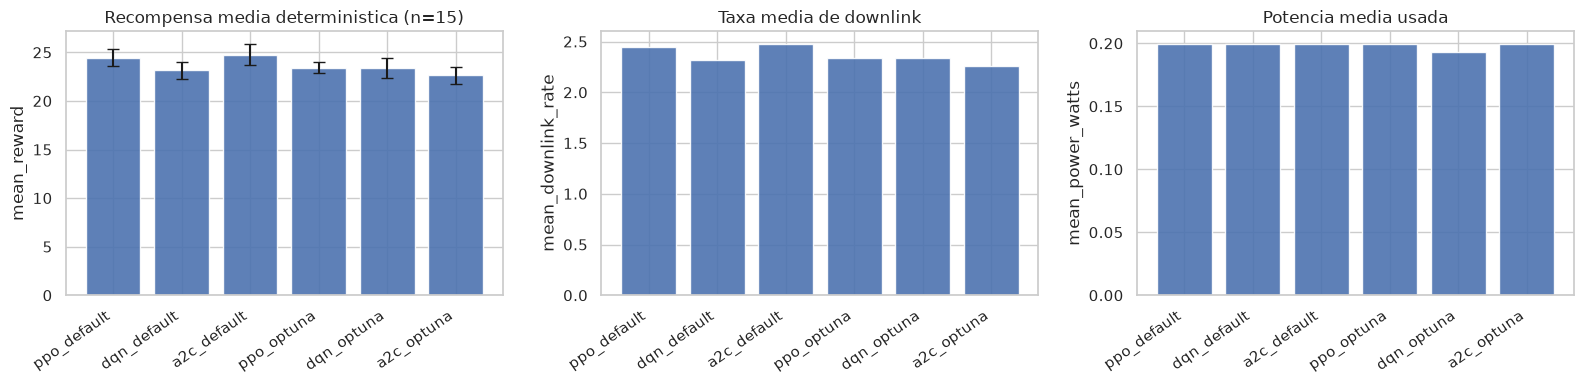

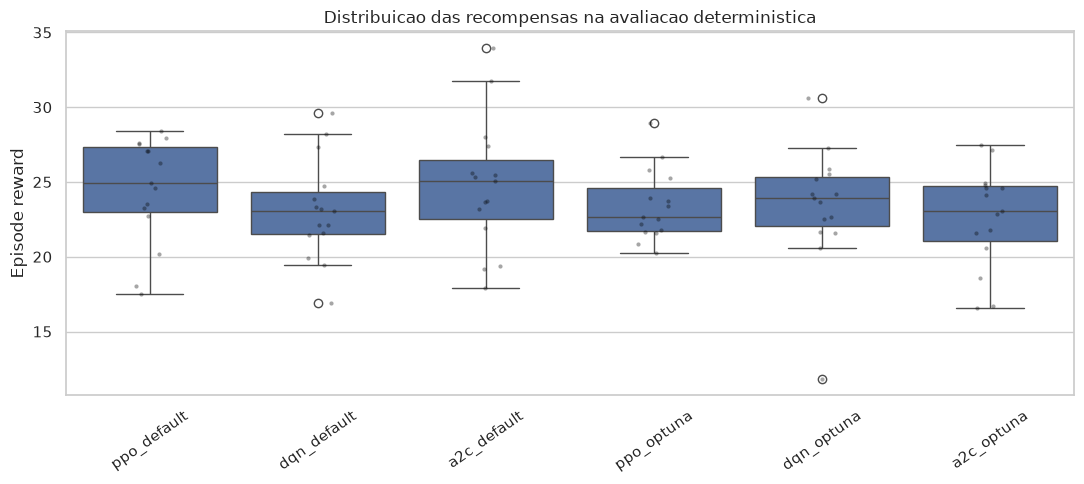

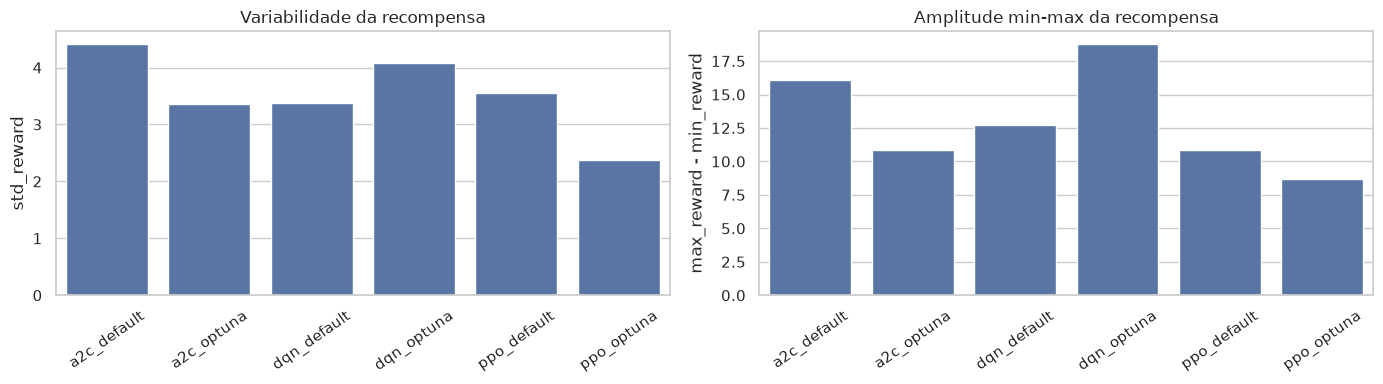

In [46]:
evaluation_df = pd.DataFrame(evaluation_records)
if evaluation_df.empty and (RUN_RESULTS_DIR / "evaluation_episodes.csv").exists():
    evaluation_df = pd.read_csv(RUN_RESULTS_DIR / "evaluation_episodes.csv")

comparison_df = results_df.copy()
comparison_df["reward_sem"] = comparison_df["std_reward"] / np.sqrt(comparison_df["eval_episodes"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(comparison_df))
labels = comparison_df["model"].tolist()
bar_color = sns.color_palette("deep", n_colors=1)[0]

axes[0].bar(x, comparison_df["mean_reward"], yerr=comparison_df["reward_sem"], capsize=4, color=bar_color, alpha=0.9)
axes[0].set_title(f"Recompensa media deterministica (n={EVAL_EPISODES})")
axes[0].set_ylabel("mean_reward")

axes[1].bar(x, comparison_df["mean_downlink_rate"], color=bar_color, alpha=0.9)
axes[1].set_title("Taxa media de downlink")
axes[1].set_ylabel("mean_downlink_rate")

axes[2].bar(x, comparison_df["mean_power_watts"], color=bar_color, alpha=0.9)
axes[2].set_title("Potencia media usada")
axes[2].set_ylabel("mean_power_watts")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "final_comparison.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=evaluation_df, x="model", y="reward", order=labels, ax=ax)
sns.stripplot(data=evaluation_df, x="model", y="reward", order=labels, color="black", alpha=0.35, size=3, ax=ax)
ax.set_title("Distribuicao das recompensas na avaliacao deterministica")
ax.set_xlabel("")
ax.set_ylabel("Episode reward")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "reward_distribution.png", dpi=150)
plt.show()

stability_df = pd.read_csv(RUN_RESULTS_DIR / "stability_summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=stability_df, x="model", y="std_reward", ax=axes[0])
axes[0].set_title("Variabilidade da recompensa")
axes[0].set_xlabel("")
axes[0].set_ylabel("std_reward")
axes[0].tick_params(axis="x", rotation=35)

reward_range = stability_df.assign(reward_range=stability_df["max_reward"] - stability_df["min_reward"])
sns.barplot(data=reward_range, x="model", y="reward_range", ax=axes[1])
axes[1].set_title("Amplitude min-max da recompensa")
axes[1].set_xlabel("")
axes[1].set_ylabel("max_reward - min_reward")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "stability_summary.png", dpi=150)
plt.show()


## 14. Historico do Optuna

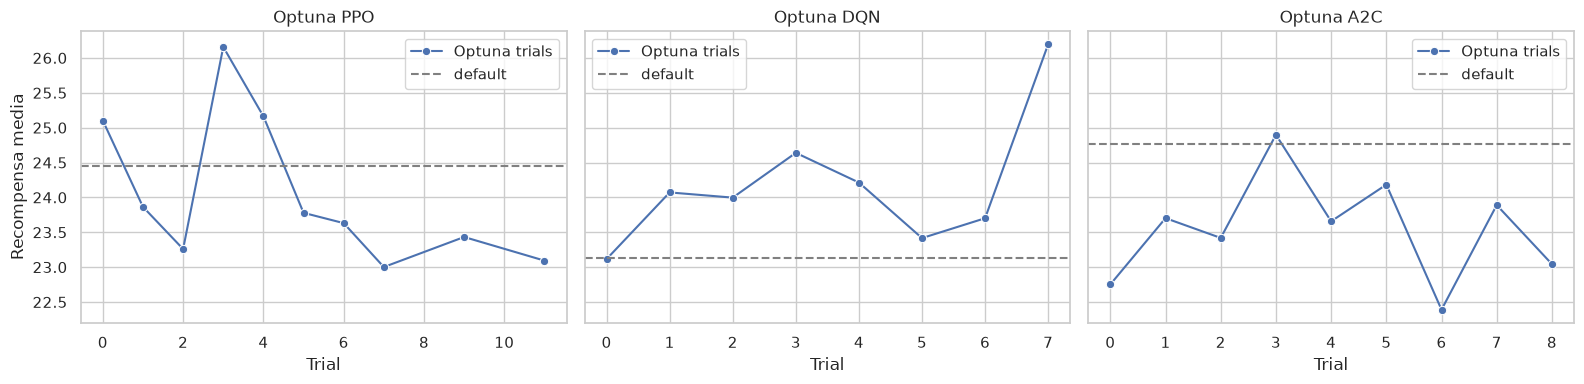

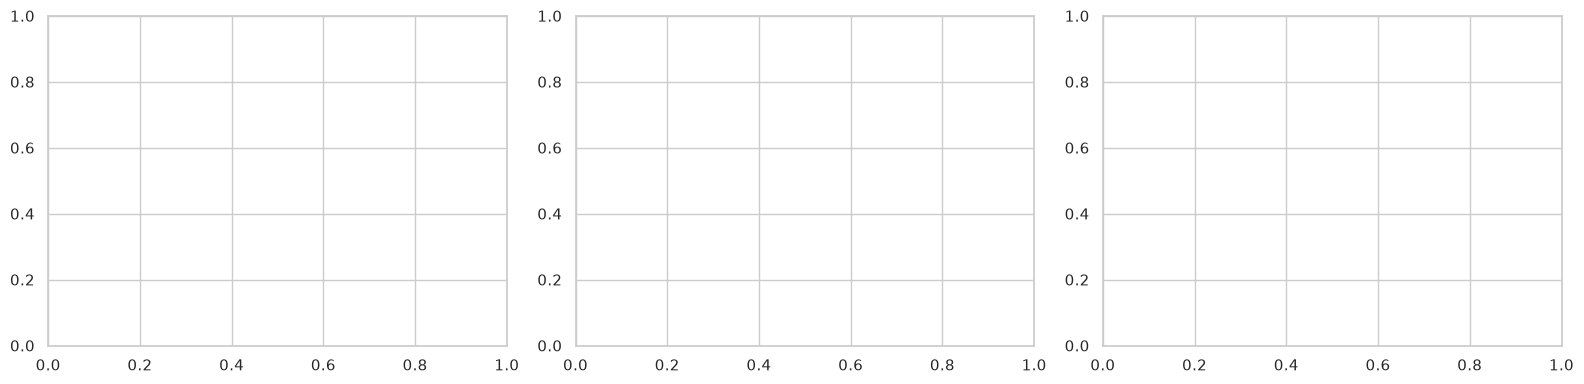

Artefatos publicados tambem em results/, figures/ e models/ como ultima execucao.


In [47]:
ppo_trials_df = study_ppo.trials_dataframe()
dqn_trials_df = study_dqn.trials_dataframe()
a2c_trials_df = study_a2c.trials_dataframe()
ppo_trials_df.to_csv(RUN_RESULTS_DIR / "optuna_ppo_trials.csv", index=False)
dqn_trials_df.to_csv(RUN_RESULTS_DIR / "optuna_dqn_trials.csv", index=False)
a2c_trials_df.to_csv(RUN_RESULTS_DIR / "optuna_a2c_trials.csv", index=False)

default_rewards = (
    results_df[results_df["training_type"] == "default"]
    .set_index("algorithm")["mean_reward"]
    .to_dict()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
trial_sets = [
    ("PPO", study_ppo, ppo_trials_df, axes[0]),
    ("DQN", study_dqn, dqn_trials_df, axes[1]),
    ("A2C", study_a2c, a2c_trials_df, axes[2]),
]

for algorithm, study, trials_df, ax in trial_sets:
    complete_trials = trials_df[trials_df["state"] == "COMPLETE"] if "state" in trials_df.columns else trials_df
    sns.lineplot(data=complete_trials, x="number", y="value", marker="o", ax=ax, label="Optuna trials")
    if algorithm in default_rewards:
        ax.axhline(default_rewards[algorithm], linestyle="--", color="gray", linewidth=1.5, label="default")
    ax.set_title(f"Optuna {algorithm}")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Recompensa media" if algorithm == "PPO" else "")
    ax.legend(loc="best")

plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "optuna_history.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for algorithm, study, trials_df, ax in trial_sets:
    try:
        importances = optuna.importance.get_param_importances(study)
    except Exception as exc:
        importances = {}
        ax.text(0.5, 0.5, f"Importancia indisponivel\n{exc}", ha="center", va="center", transform=ax.transAxes)
    if importances:
        imp_df = pd.DataFrame({"param": list(importances.keys()), "importance": list(importances.values())})
        sns.barplot(data=imp_df, x="importance", y="param", ax=ax)
    ax.set_title(f"Importancia - {algorithm}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RUN_FIGURES_DIR / "optuna_param_importance.png", dpi=150)
plt.show()

publish_latest_artifacts()
print("Artefatos publicados tambem em results/, figures/ e models/ como ultima execucao.")


## 15. Conclusao para o relatorio/apresentacao

Use os valores da tabela e dos graficos para discutir:

- se PPO, DQN ou A2C obteve maior recompensa media;
- se o Optuna melhorou cada configuracao padrao;
- como a taxa media de downlink acompanha a recompensa;
- qual custo de potencia foi observado;
- quais hiperparametros apareceram nos melhores trials.

A metrica principal do ambiente e a recompensa, que corresponde a taxa media de downlink em bits/s/Hz ao longo dos passos do episodio. Portanto, maior recompensa indica melhor alocacao de potencia para o canal simulado.

In [48]:
best_model = results_df.sort_values("mean_reward", ascending=False).iloc[0]
print("Run ID:", RUN_ID)
print("Resultados da execucao:", RUN_RESULTS_DIR)
print("Figuras da execucao:", RUN_FIGURES_DIR)
print("Modelos da execucao:", RUN_MODELS_DIR)

print("\nMelhor modelo:", best_model["model"])
print("Recompensa media:", round(best_model["mean_reward"], 4))
print("Desvio da recompensa:", round(best_model["std_reward"], 4))
print("Taxa media de downlink:", round(best_model["mean_downlink_rate"], 4))
print("Potencia media usada:", round(best_model["mean_power_watts"], 6))

print("\nMelhores parametros PPO:")
print(study_ppo.best_params)

print("\nMelhores parametros DQN:")
print(study_dqn.best_params)

print("\nMelhores parametros A2C:")
print(study_a2c.best_params)


Run ID: 20260720_170424_vasco_optuna
Resultados da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/results/runs/20260720_170424_vasco_optuna
Figuras da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/figures/runs/20260720_170424_vasco_optuna
Modelos da execucao: /home/juan/documents/projeto_ic_MIMO/VASCO_final_project/models/runs/20260720_170424_vasco_optuna

Melhor modelo: a2c_default
Recompensa media: 24.7674
Desvio da recompensa: 4.2652
Taxa media de downlink: 2.4767
Potencia media usada: 0.199526

Melhores parametros PPO:
{'n_steps': 2048, 'batch_size': 128, 'learning_rate': 5.432176219989315e-05, 'gamma': 0.9517645562137688, 'gae_lambda': 0.9009195079319672, 'clip_range': 0.21403935408357594, 'ent_coef': 0.004386015134623203}

Melhores parametros DQN:
{'learning_rate': 0.00015236917933309359, 'buffer_size': 50000, 'learning_starts': 2000, 'batch_size': 256, 'gamma': 0.9973109838451991, 'train_freq': 1, 'gradient_steps': 1, 'target_update_inter